In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [2]:
# Load dataset
df = pd.read_csv('C:/Users/vrund/Downloads/ML/amazon_sales_2025_INR.csv')
df.head()


,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,25-01-2025,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,28-08-2025,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,27-02-2025,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,24-02-2025,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,15-06-2025,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India


In [3]:
# Keep only numeric columns
df = df.select_dtypes(include=[np.number]).dropna()

# Target column (last numeric column)
target = df.columns[-1]

# Features and target
X = df.drop(target, axis=1)
y = df[target]


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# Model training
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Cross-validation
scores = cross_val_score(
    model, X, y, cv=5, scoring='neg_mean_squared_error'
)

# Convert negative MSE to RMSE
scores = np.sqrt(-scores)
scores


array([1.70957158, 1.65595012, 1.69359717, 1.6915617 , 1.69565679])

In [7]:
# Save results
df_res = pd.DataFrame({
    'Fold': range(1, len(scores)+1),
    'RMSE': scores
})

df_res.to_csv('RQ6_table.csv', index=False)
df_res


,Fold,RMSE
0,1,1.709572
1,2,1.655950
2,3,1.693597
3,4,1.691562
4,5,1.695657


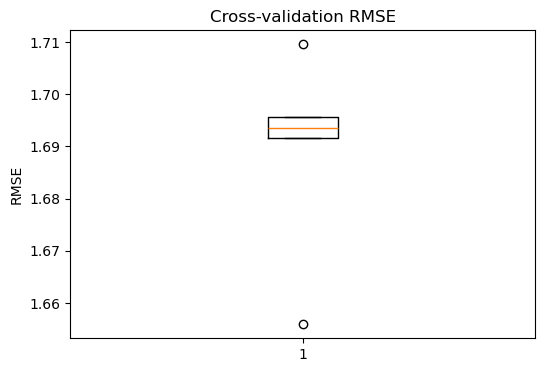

In [9]:
# Plot results
plt.figure(figsize=(6,4))
plt.boxplot(scores)
plt.title('Cross-validation RMSE')
plt.ylabel('RMSE')
plt.savefig('RQ6_figure.pdf')
plt.show()
